# M4 — The delta rule / DeltaNet

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/foundations/m4-delta-rule.ipynb)

**The question:** how does a memory *edit* an association instead of piling onto it?

Fourth module of the foundations spine. Runs on CPU in seconds; PyTorch throughout.

M3 ended on a wall: linear attention's memory only ever *adds* ($\mathbf{S}_t=\mathbf{S}_{t-1}+\mathbf{v}_t\phi(\mathbf{k}_t)^\top$), so writing twice to the same key returns the **sum** of both values, and recall is lossy under load (M3 §6). M4 fixes the *write rule*: before storing, **read what's already there for this key and write only the difference**. That single change turns a pile-on memory into one that can *edit* associations.

The fix is not new. It is the **delta rule**, which Bernard Widrow and Marcian Hoff published in [1960](https://isl.stanford.edu/~widrow/papers/c1960adaptiveswitching.pdf) (*Adaptive Switching Circuits*, IRE WESCON Convention Record, pp. 96–104) as the learning rule for Adaline — adjust the weights by the *error* between what you wanted and what you got. It predates backpropagation, deep learning, and Transformers by decades; what M4 does is recognize that a sequence model's memory has exactly the problem Widrow and Hoff's adaptive circuit had, and reach for the same answer. A linear Transformer with this write is a **DeltaNet**.

## Objective

After this module you should be able to:

- Show concretely why the **additive** write cannot *update* an association — it accumulates, returning $\mathbf{v}_1+\mathbf{v}_2$ when you meant to overwrite $\mathbf{v}_1$ with $\mathbf{v}_2$.
- Write the **delta rule**: read $\bar{\mathbf{v}}=\mathcal{M}\phi(\mathbf{k})$, then write $\beta(\mathbf{v}-\bar{\mathbf{v}})\phi(\mathbf{k})^\top$ — *write the new, remove the old* (FWP Eqs. 20–24).
- Recognize the delta write as **one step of gradient descent** on the regression loss $\tfrac12\lVert\mathcal{M}\phi(\mathbf{k})-\mathbf{v}\rVert^2$ — the "objective dial" from M2: swap the dot-product objective (→ Hebbian) for an $L_2$ one (→ delta).
- Read the update in **matrix form** $\mathcal{M}(I-\beta\mathbf{k}\mathbf{k}^\top)+\beta\mathbf{v}\mathbf{k}^\top$ and see that $(I-\beta\mathbf{k}\mathbf{k}^\top)$ **erases only along $\mathbf{k}$** — a *targeted* edit, unlike a global decay gate that fades every key.
- Explain why the delta rule wins in the **overcapacity / revisited-key regime** (FWP's setting-2 experiment), and where $\beta$ (a learned, dynamic write strength) comes from.

## Why it exists (the limitation it fixes)

M3's memory is purely additive. Two problems, one root:

1. **It can't overwrite.** Store $(\mathbf{k},\mathbf{v}_1)$, later store $(\mathbf{k},\mathbf{v}_2)$ — the additive rule gives $\mathcal{M}=\mathbf{v}_1\mathbf{k}^\top+\mathbf{v}_2\mathbf{k}^\top$, so a query returns $\mathbf{v}_1+\mathbf{v}_2$. There is no way to *replace* a value; the memory only ever grows.
2. **It saturates.** A fixed $d\times d$ matrix holds about $d$ near-orthogonal associations (M2's capacity law). Past that — the **overcapacity regime** — new writes interfere with old ones and recall degrades (M3 §6).

The [FWP paper](https://arxiv.org/abs/2102.11174) frames the fix precisely (§4.2): once in overcapacity, *"an ideal memory model should dynamically interact with the memory contents and selectively determine which associations to remember or to forget … the purely additive update rule may be sub-optimal."* The answer is to make the write **error-correcting**: look at what the memory currently returns for this key, and only write the part it's getting *wrong*. That is the delta rule, and it's the first write rule in this course that can *edit* rather than only *append* — the real fix to the crosstalk wall we've now hit in M1, M2, and M3.

## Core idea — read before you write

Linear attention writes blindly: $\mathcal{M}_t=\mathcal{M}_{t-1}+\mathbf{v}_t\phi(\mathbf{k}_t)^\top$. The delta rule inserts one step first — **read the memory at this key**, then write the *correction* (FWP Eqs. 20, 24; $\bar{\mathbf{v}}$ is what's currently stored, $\beta$ a write strength):

$$\bar{\mathbf{v}}_t=\mathcal{M}_{t-1}\,\phi(\mathbf{k}_t),\qquad \boxed{\;\mathcal{M}_t=\mathcal{M}_{t-1}+\beta_t\,(\mathbf{v}_t-\bar{\mathbf{v}}_t)\,\phi(\mathbf{k}_t)^\top\;}$$

Carrying Widrow and Hoff's 1960 rule into a fast-weight memory is [FWP](https://arxiv.org/abs/2102.11174)'s move (Schlag, Irie & Schmidhuber, 2021, §4.2), and the paper is explicit that it is borrowing: it introduces "an improved programming instruction akin to the famous error-correcting delta-rule," citing Widrow & Hoff for the rule itself. It derives it as **write-the-new, remove-the-old** (Eq. 23): $\mathcal{M}_t=\mathcal{M}_{t-1}\underbrace{+\,\mathbf{v}^{\text{new}}_t\phi(\mathbf{k}_t)^\top}_{\text{write}}\underbrace{-\,\bar{\mathbf{v}}_t\phi(\mathbf{k}_t)^\top}_{\text{remove}}$, which collapses to the boxed form. Three ways to read it, all the same equation:

- **Error correction** (Widrow–Hoff): write only the residual $\mathbf{v}_t-\bar{\mathbf{v}}_t$ between what you want and what's stored. If the key is already correct, $\bar{\mathbf{v}}_t=\mathbf{v}_t$ and *nothing is written*.
- **Gradient step:** the residual is the gradient of $\tfrac12\lVert\mathcal{M}\phi(\mathbf{k})-\mathbf{v}\rVert^2$, so one delta write = one SGD step with learning rate $\beta_t$ (§3 below).
- **Erase-then-write:** in matrix form $\mathcal{M}_t=\mathcal{M}_{t-1}(I-\beta_t\phi(\mathbf{k}_t)\phi(\mathbf{k}_t)^\top)+\beta_t\mathbf{v}_t\phi(\mathbf{k}_t)^\top$ — a *targeted* rank-1 erase along $\mathbf{k}_t$, then a write (§4 below).

$\beta_t=\sigma(W_\beta\mathbf{x}_t)$ is a **learned, per-token write strength** (FWP Eq. 21) — the model's self-invented, dynamically changing learning rate. A linear Transformer with this write is what FWP names a **Delta Network (DeltaNet)**.

### Reading

- [FWP](https://arxiv.org/abs/2102.11174) — §4.2 (Eqs. 20–24, the delta instruction; Eq. 23, write-the-new/remove-the-old), §6.1.2 (the setting-2 revisited-key experiment), App. A.1 (the derivation). The grounding source.
- Modern parallel form: [Parallelizing Linear Transformers with the Delta Rule over Sequence Length](https://arxiv.org/abs/2406.06484) (Yang, Wang, Zhang, Shen & Kim, 2024) — the chunked DeltaNet used to train at scale.

## 1. The failure: additive memory can't update

First, feel the problem directly. Store value $\mathbf{v}_1$ at key $\mathbf{k}$, then later store $\mathbf{v}_2$ at the **same** key with the additive (M3) rule. With $\mathbf{k}$ unit-norm, a query returns $\mathcal{M}\mathbf{k}=\mathbf{v}_1+\mathbf{v}_2$ — the *sum* of everything ever written there, not the latest value.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
d = 16
k  = F.normalize(torch.randn(d), dim=0)
v1, v2 = torch.randn(d), torch.randn(d)

def sum_write(M, k, v, beta=1.0):
    return M + beta * torch.outer(v, k)          # additive Hebbian write (M1 / M3)

M = torch.zeros(d, d)
M = sum_write(M, k, v1)                           # store (k -> v1)
M = sum_write(M, k, v2)                           # same key, new value v2
recall = M @ k                                    # k is unit-norm -> v1 + v2
print(f"want v2:  additive recall error vs v2       = {(recall - v2).norm()/v2.norm():.3f}")
print(f"          additive recall error vs (v1+v2)  = {(recall - (v1+v2)).norm()/(v1+v2).norm():.3f}")
print("additive memory cannot overwrite: it returns v1+v2, the SUM of all writes at k.")

want v2:  additive recall error vs v2       = 1.235
          additive recall error vs (v1+v2)  = 0.000
additive memory cannot overwrite: it returns v1+v2, the SUM of all writes at k.


## 2. The delta rule: read $\bar{\mathbf{v}}$, write the correction

Now insert the read. Before writing, query the memory at $\mathbf{k}$ to get $\bar{\mathbf{v}}=\mathcal{M}\mathbf{k}$ — the *stale* value — and write only $\mathbf{v}-\bar{\mathbf{v}}$. On the second write the memory already holds $\mathbf{v}_1$, so $\bar{\mathbf{v}}=\mathbf{v}_1$ and we write $\mathbf{v}_2-\mathbf{v}_1$: the key now stores exactly $\mathbf{v}_2$. The same repeated-key test that broke the additive rule is now clean.

In [2]:
def delta_write(M, k, v, beta=1.0):
    v_bar = M @ k                                 # READ the current value at this key (FWP Eq. 20)
    return M + beta * torch.outer(v - v_bar, k)   # write only the CORRECTION (FWP Eq. 24)

M = torch.zeros(d, d)
M = delta_write(M, k, v1)                          # v_bar = 0   -> writes v1
M = delta_write(M, k, v2)                          # v_bar = v1  -> writes (v2 - v1)
recall = M @ k
print(f"want v2:  delta recall error vs v2 = {(recall - v2).norm()/v2.norm():.3f}")
print("read-before-write: subtract the stale value, add the new one -> the key is UPDATED, not piled onto.")
print("if the key is already correct, v_bar == v and the write is zero -- nothing is disturbed.")

want v2:  delta recall error vs v2 = 0.000
read-before-write: subtract the stale value, add the new one -> the key is UPDATED, not piled onto.
if the key is already correct, v_bar == v and the write is zero -- nothing is disturbed.


## 3. The delta write *is* one gradient step

Why does "write the residual" work? Because the residual **is a gradient**. Take the regression loss that asks the memory to map this key to this value,

$$\mathcal{L}(\mathcal{M})=\tfrac12\big\lVert\mathcal{M}\mathbf{k}-\mathbf{v}\big\rVert^2,\qquad \nabla_{\mathcal{M}}\mathcal{L}=(\mathcal{M}\mathbf{k}-\mathbf{v})\,\mathbf{k}^\top=(\bar{\mathbf{v}}-\mathbf{v})\,\mathbf{k}^\top.$$

One gradient-descent step $\mathcal{M}-\beta\nabla_{\mathcal{M}}\mathcal{L}=\mathcal{M}+\beta(\mathbf{v}-\bar{\mathbf{v}})\mathbf{k}^\top$ is *exactly* the delta write. So the memory isn't just storing — it's **learning at test time**, one SGD step per token, with $\beta$ the learning rate. This is the **objective dial** from M2 made concrete: the Hebbian write *ascends* the dot-product objective $\langle\mathcal{M}\mathbf{k},\mathbf{v}\rangle$; the delta write *descends* the $L_2$ objective $\tfrac12\lVert\mathcal{M}\mathbf{k}-\mathbf{v}\rVert^2$. (This thread — *the write as a gradient step* — is exactly what [Titans](../tracks/nested-learning/nl1-test-time-learning.ipynb) generalize to many steps / a deeper inner objective, and what [M6](m6-optimizers-as-memory.ipynb) reads back onto the optimizer itself.)

delta write == one GD step on 1/2||Mk - v||^2 : True


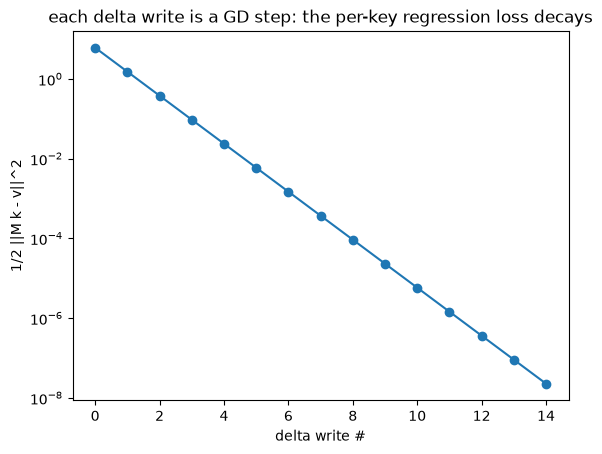

Hebbian ASCENDS <Mk,v> (dot-product objective); delta DESCENDS 1/2||Mk-v||^2 (L2 objective).


In [3]:
torch.manual_seed(1)
M0   = torch.randn(d, d) * 0.1
kk   = F.normalize(torch.randn(d), dim=0)
vv   = torch.randn(d)
beta = 0.5

# (a) one delta write
v_bar   = M0 @ kk
M_delta = M0 + beta * torch.outer(vv - v_bar, kk)

# (b) one SGD step on  L = 1/2 ||M k - v||^2   (autograd computes the gradient)
Mg = M0.clone().requires_grad_(True)
L  = 0.5 * ((Mg @ kk - vv)**2).sum()
L.backward()
M_sgd = M0 - beta * Mg.grad

print("delta write == one GD step on 1/2||Mk - v||^2 :", torch.allclose(M_delta, M_sgd, atol=1e-6))

# repeated delta writes = repeated GD steps -> the loss decays toward zero
losses, M = [], M0.clone()
for _ in range(15):
    losses.append(0.5 * ((M @ kk - vv)**2).sum().item())
    M = delta_write(M, kk, vv, beta=0.5)
plt.plot(losses, marker='o'); plt.yscale('log')
plt.xlabel("delta write #"); plt.ylabel("1/2 ||M k - v||^2")
plt.title("each delta write is a GD step: the per-key regression loss decays"); plt.show()
print("Hebbian ASCENDS <Mk,v> (dot-product objective); delta DESCENDS 1/2||Mk-v||^2 (L2 objective).")

## 4. Erase-then-write — a *targeted* edit, not a global fade

Expand the delta write and a clean structure appears:

$$\mathcal{M}+\beta(\mathbf{v}-\mathcal{M}\mathbf{k})\mathbf{k}^\top=\mathcal{M}\big(I-\beta\,\mathbf{k}\mathbf{k}^\top\big)+\beta\,\mathbf{v}\mathbf{k}^\top.$$

The factor $(I-\beta\mathbf{k}\mathbf{k}^\top)$ is a rank-1 projector that **subtracts only the component along $\mathbf{k}$** — it erases the *old* association at this key and leaves every direction orthogonal to $\mathbf{k}$ untouched — then $\beta\mathbf{v}\mathbf{k}^\top$ writes the new one. Contrast the **gated** rule (FWP Eq. 52) $\mathcal{M}_t=(1-\beta)\mathcal{M}_{t-1}+\beta\mathbf{v}_t\mathbf{k}_t^\top$, the global forget used by the gated linear-attention family — [RetNet](https://arxiv.org/abs/2307.08621) (Sun et al., 2023) with a decay fixed per head, [Mamba-2](https://arxiv.org/abs/2405.21060) (Dao & Gu, 2024) with one the input chooses: it decays *all* of memory uniformly on every write. The demo stores several orthonormal keys, updates **one**, and checks an untouched key: the delta edit preserves it exactly; the global gate fades it.

### The gated delta rule — why the contrast is not a verdict

The demo makes the gate look strictly worse, and for *this* test it is. But a global fade is the only way to clear memory **wholesale**, which is what you want when the context genuinely turns over and everything stored is now stale — and that is exactly what a targeted edit cannot do, since it only ever touches one key at a time. The two rules fail in opposite directions.

[Gated DeltaNet](https://arxiv.org/abs/2412.06464) (Yang, Kautz & Hatamizadeh, 2024) is the paper that stopped choosing. Its observation is the one this section has been circling — *"gating enables rapid memory erasure while the delta rule facilitates targeted updates"* — and its move is to introduce the **gated delta rule** (Eq. 8), which slips a data-dependent scalar gate $\alpha_t\in(0,1)$ inside the delta write so one rule can both fade the whole memory and revise a single key:

$$\mathcal{M}_t=\mathcal{M}_{t-1}\big(\alpha_t(I-\beta_t\,\mathbf{k}_t\mathbf{k}_t^\top)\big)+\beta_t\,\mathbf{v}_t\mathbf{k}_t^\top.$$

Set $\alpha_t=1$ and you are back at the delta rule above; drop the $(I-\beta_t\mathbf{k}_t\mathbf{k}_t^\top)$ factor and what remains is the gated Hebbian write, Mamba-2's row up to the $\beta_t$ write strength. Neither ancestor was invented from nothing: the projector is Widrow and Hoff's 1960 error correction routed through FWP, the gate is Mamba-2's, and the paper's own title — *Gated Delta Networks: Improving Mamba2 with Delta Rule* — names both parents. Two independent dials, which is exactly how [M7](m7-three-dials.ipynb) §5 sorts the family.

In [4]:
torch.manual_seed(2)
d = 16
Qm, _ = torch.linalg.qr(torch.randn(d, d))
keys  = Qm[:, :5].t()                 # 5 orthonormal keys (rows)
vals  = torch.randn(5, d)

M = torch.zeros(d, d)                  # store all 5 cleanly with delta
for k_, v_ in zip(keys, vals):
    M = delta_write(M, k_, v_, beta=1.0)

# matrix form: M (I - beta k k^T) + beta v k^T
def delta_write_matrix(M, k, v, beta=1.0):
    I = torch.eye(M.shape[1])
    return M @ (I - beta * torch.outer(k, k)) + beta * torch.outer(v, k)

def gated_write(M, k, v, beta):                       # FWP Eq. 52: global decay of ALL memory
    return (1 - beta) * M + beta * torch.outer(v, k)

new_v = torch.randn(d)
print("delta write == M(I - beta k k^T) + beta v k^T :",
      torch.allclose(delta_write(M.clone(), keys[0], new_v, 0.9),
                     delta_write_matrix(M.clone(), keys[0], new_v, 0.9), atol=1e-5))

beta = 0.9
M_delta = delta_write(M.clone(), keys[0], new_v, beta)
M_gated = gated_write(M.clone(), keys[0], new_v, beta)
print(f"\nafter updating key 0 (beta={beta}):")
for name, Mx in [("delta", M_delta), ("global-gate", M_gated)]:
    upd  = (Mx @ keys[0] - new_v).norm()  / new_v.norm()     # did key 0 update?
    keep = (Mx @ keys[3] - vals[3]).norm() / vals[3].norm()  # is untouched key 3 intact?
    print(f"  {name:12s}  key0 update err {upd:.3f}   key3 (untouched) recall err {keep:.3f}")
print("delta erases ONLY along k0 (I - k0 k0^T): key3 is untouched. The global gate fades EVERY key.")

delta write == M(I - beta k k^T) + beta v k^T : True

after updating key 0 (beta=0.9):
  delta         key0 update err 0.132   key3 (untouched) recall err 0.000
  global-gate   key0 update err 0.132   key3 (untouched) recall err 0.900
delta erases ONLY along k0 (I - k0 k0^T): key3 is untouched. The global gate fades EVERY key.


## 5. Where it pays off: revisited keys & overcapacity

The delta rule's headline win is FWP's **setting 2** ([§6.1.2](https://arxiv.org/abs/2102.11174)): keys are sampled *with replacement*, so the same key is reassigned a new value several times across the stream, and the model must return the **most recent** one. This is precisely "update previously acquired knowledge in a finite memory" — what the additive rule can't do.

The demo runs a stream of $2S$ writes over $S$ distinct keys and, at the end, queries each key against its latest value. The additive rule returns the running sum of *all* values ever written to a key, so its error is high everywhere; the delta rule keeps only the most recent, holding low error until the number of distinct keys outgrows the matrix capacity ($\sim d$).

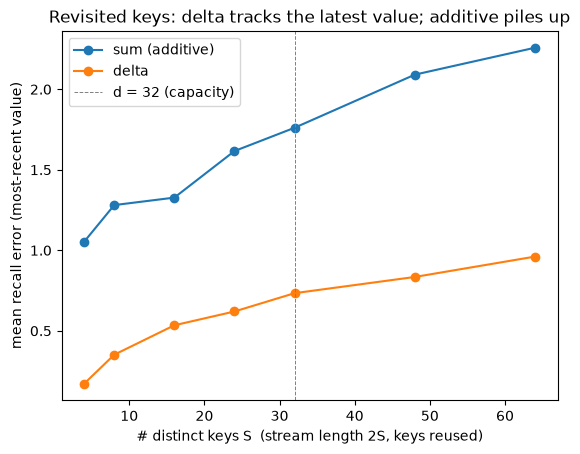

additive returns the SUM of all past values per key -> high error always.
delta keeps only the most recent -> low error until keys outnumber capacity (~d).


In [5]:
def run_stream(write_rule, S, d=32, seed=0):
    g = torch.Generator().manual_seed(seed)
    keys = F.normalize(torch.randn(S, d, generator=g), dim=1)
    M, latest = torch.zeros(d, d), {}
    for _ in range(2 * S):                          # stream length 2S: keys get revisited
        i = torch.randint(S, (1,), generator=g).item()
        v = torch.randn(d, generator=g)
        latest[i] = v                               # the value we must be able to recall
        M = write_rule(M, keys[i], v, 1.0)
    errs = torch.stack([(M @ keys[i] - latest[i]).norm() / latest[i].norm() for i in latest])
    return errs.mean().item()

Ss = [4, 8, 16, 24, 32, 48, 64]
for rule, name in [(sum_write, "sum (additive)"), (delta_write, "delta")]:
    plt.plot(Ss, [run_stream(rule, S) for S in Ss], marker='o', label=name)
plt.axvline(32, ls='--', c='gray', lw=0.7, label='d = 32 (capacity)')
plt.xlabel("# distinct keys S  (stream length 2S, keys reused)")
plt.ylabel("mean recall error (most-recent value)")
plt.title("Revisited keys: delta tracks the latest value; additive piles up")
plt.legend(); plt.show()
print("additive returns the SUM of all past values per key -> high error always.")
print("delta keeps only the most recent -> low error until keys outnumber capacity (~d).")

## 6. Decoupling erase and write — Gated DeltaNet-2

§4's matrix form hides a coupling. Read it again:

$$\mathcal{M}_t=\mathcal{M}_{t-1}\big(I-\beta_t\,\mathbf{k}_t\mathbf{k}_t^\top\big)+\beta_t\,\mathbf{v}_t\mathbf{k}_t^\top.$$

One scalar $\beta_t$ does two jobs. In the left factor it sets how hard the **old** association at $\mathbf{k}_t$ is erased; in the right term it sets how strongly the **new** value is written. But erasing and writing act on different axes of the memory — erasing decides which coordinates of the *old read* to remove (the key side), writing decides which coordinates of the *incoming value* to commit (the value side). Forcing one number to answer both is a restriction of the update, not a property of the delta rule.

[Gated DeltaNet-2](https://arxiv.org/abs/2605.22791) (Hatamizadeh, Choi & Kautz, 2026) cuts the tie. It replaces the scalar with two independent **channel-wise** gates — an erase gate $\mathbf{b}_t\in[0,1]^{d_k}$ on the key axis and a write gate $\mathbf{w}_t\in[0,1]^{d_v}$ on the value axis (§3.1, Eqs. 8–10) — forming an *erasing key* $\mathbf{b}_t\odot\mathbf{k}_t$ and a *writing value* $\mathbf{w}_t\odot\mathbf{v}_t$. In M4's memory orientation (the paper writes the state transposed, and carries a channel-wise decay $\mathbf{D}_t$ we hold at $I$ here to isolate the new idea), the *Gated Delta Rule-2* is

$$\mathcal{M}_t=\mathcal{M}_{t-1}\big(I-(\mathbf{b}_t\odot\mathbf{k}_t)\,\mathbf{k}_t^\top\big)+(\mathbf{w}_t\odot\mathbf{v}_t)\,\mathbf{k}_t^\top.$$

The write direction $\mathbf{k}_t$ is untouched, so the delta structure survives; what moved is that the *read* direction $\mathbf{b}_t\odot\mathbf{k}_t$ and the *committed* value $\mathbf{w}_t\odot\mathbf{v}_t$ are now selected coordinate by coordinate, and independently. Tie the two gates to one scalar, $\mathbf{b}_t=\mathbf{w}_t=\beta_t\mathbf{1}$, and the legs collapse back to $\beta_t\mathbf{k}_t\mathbf{k}_t^\top$ and $\beta_t\mathbf{v}_t\mathbf{k}_t^\top$ — exactly §4's line.

That reduction is a lineage. Gated DeltaNet-2 recovers **KDA** (Kimi Delta Attention, from [Kimi Linear](https://arxiv.org/abs/2510.26692); Kimi Team, 2025) when the erase and write gates tie to the same scalar, and recovers [Gated DeltaNet](https://arxiv.org/abs/2412.06464) (§4's gated rule) when the channel-wise decay collapses to a scalar too. The other way down the chain: Gated DeltaNet = delta rule + scalar decay; KDA = + channel-wise decay; Gated DeltaNet-2 = + decoupled channel-wise erase and write. The demo below builds the smallest case where the tie bites.

In [6]:
import torch
import torch.nn.functional as F

# Gated Delta Rule-2 (GDN2, Eq. 10) in M4's memory orientation, decay set to I:
#   M_t = M_{t-1}(I - (b*k) k^T) + (w*v) k^T
#   erase gate b in [0,1]^{d_k} (key axis) ,  write gate w in [0,1]^{d_v} (value axis)
# Tie b = w = beta*1  and it is exactly section 4's coupled write.
def gdn2_write(M, k, v, b, w):
    I = torch.eye(k.shape[0])
    return M @ (I - torch.outer(b * k, k)) + torch.outer(w * v, k)

def coupled_write(M, k, v, beta):                 # section 4's single-scalar delta
    I = torch.eye(k.shape[0])
    return M @ (I - beta * torch.outer(k, k)) + beta * torch.outer(v, k)

torch.manual_seed(0)
d = 4
k     = F.normalize(torch.randn(d), dim=0)         # one unit key / one memory slot
v_old = torch.tensor([1.0, -1.0,  1.2, -0.8])      # stale content sitting in the slot
v_new = torch.tensor([2.0, -1.5,  3.0, -2.5])      # incoming value...
trust = torch.tensor([1.0,  1.0,  0.0,  0.0])      # ...but only channels 0,1 are real; 2,3 are noise
target = trust * v_new                             # right answer: clear the stale slot, keep only trusted channels

M = coupled_write(torch.zeros(d, d), k, v_old, 1.0)   # store the stale value

# decoupled: erase the whole stale read (b = 1), commit only the trusted channels (w = trust)
M_dec = gdn2_write(M, k, v_new, b=torch.ones(d), w=trust)

show = lambda t: "[" + ", ".join(f"{x:+.2f}" for x in t.tolist()) + "]"
print("slot before   :", show(M @ k))
print("target        :", show(target))
print("decoupled b,w :", show(M_dec @ k), " <- clears stale, writes only trusted channels\n")
for beta in (1.0, 0.5):
    M_c = coupled_write(M, k, v_new, beta)
    print(f"coupled beta={beta}:", show(M_c @ k),
          f" err={(M_c@k - target).norm():.3f}",
          "(writes the noise)" if beta == 1.0 else "(leaves stale content behind)")

# --- two exact identities, the real tests ---
# 1. decoupled gates recover the intended state; a single scalar cannot.
assert torch.allclose(M_dec @ k, target, atol=1e-6)
assert (coupled_write(M, k, v_new, 1.0) @ k - target).norm() > 1.0
# 2. tie both gates to one scalar and GDN2 IS section 4's coupled write, to the bit.
beta = 0.7
assert torch.allclose(gdn2_write(M, k, v_new, beta*torch.ones(d), beta*torch.ones(d)),
                      coupled_write(M, k, v_new, beta), atol=1e-6)
print("\nasserts pass: decoupled hits the target, no single scalar does, and tying b=w=beta recovers section 4 exactly.")

slot before   : [+1.00, -1.00, +1.20, -0.80]
target        : [+2.00, -1.50, +0.00, -0.00]
decoupled b,w : [+2.00, -1.50, +0.00, +0.00]  <- clears stale, writes only trusted channels

coupled beta=1.0: [+2.00, -1.50, +3.00, -2.50]  err=3.905 (writes the noise)
coupled beta=0.5: [+1.50, -1.25, +2.10, -1.65]  err=2.729 (leaves stale content behind)

asserts pass: decoupled hits the target, no single scalar does, and tying b=w=beta recovers section 4 exactly.

Read the prints. The slot holds a stale value, and a new token arrives whose value is only half-trustworthy — channels 0–1 carry real content, channels 2–3 are noise that must not enter the shared state. The right update clears the slot and commits *only* the trusted channels. A single scalar cannot: at $\beta=1$ it clears the old but writes the noise; at $\beta<1$ it suppresses the noise but leaves stale content behind — the tie forces one kind of interference or the other. Decoupled, $\mathbf{b}=\mathbf{1}$ erases the whole stale read while $\mathbf{w}=[1,1,0,0]$ commits only the trusted channels, hitting the target to numerical zero. Tie the gates to one scalar and the same code reproduces §4's coupled write exactly — the reduction, run as a test.

**Honest scope.** This is a mechanism demo at toy scale: one key, decay held at $I$, gates set by hand. It isolates the one idea — erase strength and write pattern are independent — and shows the value-side write gate directly. It does *not* exercise the key-side erase gate's channel selectivity, which on a single slot can only act as a scalar; that selectivity earns its keep when many associations are packed into one finite state and compete, which is the long-context multi-key retrieval regime (RULER) where the paper reports its gains — at 1.3B parameters trained on 100B tokens, with a gate ablation (Table 5) finding both gates matter, "*the erase gate accounting for most of the gain*". Those are results to cite, not reproduce here.

## Code walkthrough — the delta write in real code

Our `delta_write` is the whole mechanism; production code differs only in batching, $\phi$, and a parallel schedule.

- **The FWP paper's own repo**, [`ischlag/fast-weight-transformers`](https://github.com/ischlag/fast-weight-transformers/tree/main/synthetic) — [`linearAttention.py`](https://github.com/ischlag/fast-weight-transformers/blob/main/synthetic/linearAttention.py) carries both the sum rule and the delta rule; [`setting2_generate_figure.ipynb`](https://github.com/ischlag/fast-weight-transformers/blob/main/synthetic/setting2_generate_figure.ipynb) is the exact revisited-key experiment we miniaturized in §5 (delta vs sum vs the Schlag-2021 variants).
- [kmccleary3301/nested_learning](https://github.com/kmccleary3301/nested_learning) keeps the delta rule as an isolated, testable unit — see [`tests/test_cms_delta_rule.py`](https://github.com/kmccleary3301/nested_learning/blob/main/tests/test_cms_delta_rule.py) and [`tests/test_phase2_memorization_delta.py`](https://github.com/kmccleary3301/nested_learning/blob/main/tests/test_phase2_memorization_delta.py); the read-then-correct write lives in [`fast_state.py`](https://github.com/kmccleary3301/nested_learning/blob/main/src/nested_learning/fast_state.py).
- **Parallel/chunked DeltaNet** ([Yang et al., 2024](https://arxiv.org/abs/2406.06484)) rewrites the sequential loop as a matmul over chunks so it trains at GPU speed — the same $\mathcal{M}(I-\beta\mathbf{k}\mathbf{k}^\top)+\beta\mathbf{v}\mathbf{k}^\top$ recurrence, scheduled like M3's parallel form. This is what made DeltaNet trainable at scale: the delta rule sat unparallelized for three years after FWP because each write depends on a read of the state the previous write produced, and the paper's fix is to represent a chunk's worth of those updates as a product of Householder matrices. The [`flash-linear-attention`](https://github.com/fla-org/flash-linear-attention) library's `delta_rule` is the reference implementation.

The one new ingredient over M3's `FWPLayer` is the **read** $\bar{\mathbf{v}}=\mathcal{M}\phi(\mathbf{k})$ before the write — one extra matrix-vector product per token.

## Exit check

Ready for M5 when you can:

1. Show why additive memory returns $\mathbf{v}_1+\mathbf{v}_2$ for a twice-written key, and how the read $\bar{\mathbf{v}}=\mathcal{M}\mathbf{k}$ fixes it.
2. Write the delta rule $\mathcal{M}_t=\mathcal{M}_{t-1}+\beta_t(\mathbf{v}_t-\bar{\mathbf{v}}_t)\phi(\mathbf{k}_t)^\top$ and say what $\beta_t$ is and where it comes from.
3. Derive "delta write = one SGD step on $\tfrac12\lVert\mathcal{M}\mathbf{k}-\mathbf{v}\rVert^2$," and name the objective each of Hebbian / delta optimizes.
4. Explain the erase-then-write matrix form and why it's a *targeted* edit, unlike a global decay gate.
5. Say why a single $\beta_t$ ties erase to write, and how Gated Delta Rule-2 (§6) splits it into a channel-wise erase gate $\mathbf{b}_t$ (key side) and write gate $\mathbf{w}_t$ (value side) — and what tying $\mathbf{b}_t=\mathbf{w}_t=\beta_t\mathbf{1}$ recovers.

**Next.** The delta rule fixed the write inside the sequence memory. But there is a second additive write in every model you have ever trained — the optimizer, piling gradients onto a memory of the gradient stream. [M6 applies exactly this fix, one level up](m6-optimizers-as-memory.ipynb). First, [M5](m5-meta-learning-self-reference.ipynb) gives the machinery of adaptation.